In [1]:
include("BarrierSynthesis.jl")

compute_next_level_barriersPM (generic function with 1 method)

# 0. Init system variable and parameters

In [2]:
#init state and input variables
@polyvar u[1:2]
@polyvar(x[1:7]) # x[1] is x, x[2] is y, x[3] is vel_x, x[4] is vel_y, x[5] is θ, x[6] is ω, x[7] is error

#define system dynamics
dynamics = [
        (ctrl -> [x[3],x[4], (ctrl[1]+ctrl[2])*(-2.0/π)*(x[5]+π)-0.2x[7], (ctrl[1]+ctrl[2])*((2.0/π)*(x[5] + π/2.0)-0.2x[7])-2, x[6], ctrl[1]-ctrl[2], 0.]),
        (ctrl -> [x[3],x[4], (ctrl[1]+ctrl[2])*(2.0/π)*x[5]+0.2x[7], (ctrl[1]+ctrl[2])*((2.0/π)*(x[5] + π/2.0)-0.2x[7])-2, x[6], ctrl[1]-ctrl[2], 0.]),
        (ctrl -> [x[3],x[4], (ctrl[1]+ctrl[2])*(2.0/π)*x[5]+0.2x[7], (ctrl[1]+ctrl[2])*((-2.0/π)*(x[5] - π/2.0)+0.2x[7])-2, x[6], ctrl[1]-ctrl[2], 0.]),
        (ctrl -> [x[3],x[4], (ctrl[1]+ctrl[2])*(-2.0/π)*(x[5]-π)-0.2x[7], (ctrl[1]+ctrl[2])*((-2.0/π)*(x[5] - π/2.0)+0.2x[7])-2, x[6], ctrl[1]-ctrl[2], 0.]),
    ]

#define unsafe set (obstacle)
g = 0.1^2 - x[1]^2 - x[2]^2 # Obstacle: is a (x,y) ball of radius 0.1 around origin

#state and input bounds
bounds = [[-10., 10.], [-10., 10.], [-10.,10.], [-10.,10.],[-π,π], [-10.,10.],[-1.,1.]]

7-element Vector{Vector{Float64}}:
 [-10.0, 10.0]
 [-10.0, 10.0]
 [-10.0, 10.0]
 [-10.0, 10.0]
 [-3.141592653589793, 3.141592653589793]
 [-10.0, 10.0]
 [-1.0, 1.0]

In [3]:
vector_field = [
        ([x[3],x[4], (u[1]+u[2])*(-2.0/π)*(x[5]+π)-0.2x[7], (u[1]+u[2])*((2.0/π)*(x[5] + π/2.0)-0.2x[7])-2, x[6], u[1]-u[2], 0.]),
        ([x[3],x[4], (u[1]+u[2])*(2.0/π)*x[5]+0.2x[7], (u[1]+u[2])*((2.0/π)*(x[5] + π/2.0)-0.2x[7])-2, x[6], u[1]-u[2], 0.]),
        ([x[3],x[4], (u[1]+u[2])*(2.0/π)*x[5]+0.2x[7], (u[1]+u[2])*((-2.0/π)*(x[5] - π/2.0)+0.2x[7])-2, x[6], u[1]-u[2], 0.]),
        ([x[3],x[4], (u[1]+u[2])*(-2.0/π)*(x[5]-π)-0.2x[7], (u[1]+u[2])*((-2.0/π)*(x[5] - π/2.0)+0.2x[7])-2, x[6], u[1]-u[2], 0.]),
]

4-element Vector{Vector{Polynomial{DynamicPolynomials.Commutative{DynamicPolynomials.CreationOrder}, Graded{LexOrder}, Float64}}}:
 [x₃, x₄, -0.2x₇ - 2.0u₂ - 2.0u₁ - 0.6366197723675814u₂x₅ - 0.6366197723675814u₁x₅, -2.0 + u₂ + u₁ - 0.2u₂x₇ + 0.6366197723675814u₂x₅ - 0.2u₁x₇ + 0.6366197723675814u₁x₅, x₆, -u₂ + u₁, 0.0]
 [x₃, x₄, 0.2x₇ + 0.6366197723675814u₂x₅ + 0.6366197723675814u₁x₅, -2.0 + u₂ + u₁ - 0.2u₂x₇ + 0.6366197723675814u₂x₅ - 0.2u₁x₇ + 0.6366197723675814u₁x₅, x₆, -u₂ + u₁, 0.0]
 [x₃, x₄, 0.2x₇ + 0.6366197723675814u₂x₅ + 0.6366197723675814u₁x₅, -2.0 + u₂ + u₁ + 0.2u₂x₇ - 0.6366197723675814u₂x₅ + 0.2u₁x₇ - 0.6366197723675814u₁x₅, x₆, -u₂ + u₁, 0.0]
 [x₃, x₄, -0.2x₇ + 2.0u₂ + 2.0u₁ - 0.6366197723675814u₂x₅ - 0.6366197723675814u₁x₅, -2.0 + u₂ + u₁ + 0.2u₂x₇ - 0.6366197723675814u₂x₅ + 0.2u₁x₇ - 0.6366197723675814u₁x₅, x₆, -u₂ + u₁, 0.0]

In [4]:
#instantiate parameters
K=1.0
δ=0.5
ϵ = 0.1
α = 0.6
max_degree=4
ul = 2.
U = [[0., 0.], [0., ul], [ul, 0.], [ul, ul]]
n_tests = 400
u_bounds = [[0, ul], [0, ul]]

2-element Vector{Vector{Float64}}:
 [0.0, 2.0]
 [0.0, 2.0]

In [5]:
# generate test points
test_pts = [ get_random(bounds, g) for _ in 1:n_tests];

# 1. Computing initial set of barriers for each input U_i

In [6]:
function findRepulsiveBarrier_HybridPM(x, ctrl::Vector{Float64}, g, dynamics, test_pts; max_degree=4, ϵ=1.0, τ=0.1, γ=10.0, K=1.0, δ=1.0, α=1.0, state_bounds=bounds)
    function prepare_domain_hybrid(var, lb, ub)
        dom = @set(var >= lb) ∩ @set(var <= ub) ∩ @set((var - lb) * (ub - var) >= 0)
        return dom
    end

    @assert τ > 0.0 "τ must be positive."
    @assert δ > 0.0 "δ must be positive."
    @assert K >= 0.0 "K must be nonnegative."
    @assert α > 0.0 "α must be positive."

    λ = (1.0 / τ) * log(1.0 + K / δ)

    solver = optimizer_with_attributes(MosekTools.Optimizer)
    model = SOSModel(solver)

    monos = monomials(x, 0:max_degree)
    N = length(monos)
    @variable(model, -γ <= c[1:N] <= γ)
    B = polynomial(c[1:end], monos)

    dom_list = prepare_domain(x, state_bounds)
    D = reduce((s1, s2) -> s1 ∩ s2, dom_list)
    println("Domain: $D")

    # 1) Unsafe-set positivity on obstacle states (g >= 0 denotes the obstacle interior)
    @constraint(model, B >= ϵ, domain = D ∩ @set(g >= 0))

    # 2) Decrease condition under each hybrid mode and fixed control
    for (i, dyn_i) in enumerate(dynamics)
        dyn_with_ctrl = dyn_i(ctrl)
        dBdt = dot(differentiate(B, x), dyn_with_ctrl)
        dom_i = prepare_domain_hybrid(x[5], (i - 3) * π / 2, (i - 2) * π / 2)
        @constraint(model, dBdt <= λ * B, domain = D ∩ dom_i)
    end

    # 3) Bounded-jump condition: B(y - yo, z) - B(y, z) <= K for yo in obstacle set
    @polyvar q1 q2
    Qα = @set(α^2 - q1^2 - q2^2 >= 0)
    B_shift = subs(B, x[1] => x[1] - q1, x[2] => x[2] - q2)
    @constraint(model, K >= B_shift - B, domain = D ∩ Qα)

    set_objective_sense(model, MOI.FEASIBILITY_SENSE)
    objective_fn = sum((B(pt...) for pt in test_pts); init=0.0)
    # With unsafe encoded as B > 0, minimize B on test points to expand certified safe set B <= 0.
    @objective(model, Min, objective_fn)

    JuMP.optimize!(model)
    stat = JuMP.primal_status(model)
    solution_summary(model)
    println("Status obtained: $(stat)")

    if stat != FEASIBLE_POINT
        return missing
    end

    return value(B), K
end

findRepulsiveBarrier_HybridPM (generic function with 1 method)

In [7]:
res_1 = findRepulsiveBarrier_HybridPM(x, U[1], g, dynamics, test_pts; K, δ, α)
@assert res_1 !== missing "Failed to synthesize barrier for U[1]"
B_1, K_1 = res_1
display(B_1)
display(K_1)
# Keep points not yet certified safe (B > 0) for subsequent barrier synthesis.
test_pts = filter!(pt -> B_1(pt...) > 0.0, test_pts)

Domain: { (x[1], x[2], x[3], x[4], x[5], x[6], x[7]) | 10.0 + x[1] ≥ 0, 10.0 - x[1] ≥ 0, 100.0 - x[1]^2 ≥ 0, 10.0 + x[2] ≥ 0, 10.0 - x[2] ≥ 0, 100.0 - x[2]^2 ≥ 0, 10.0 + x[3] ≥ 0, 10.0 - x[3] ≥ 0, 100.0 - x[3]^2 ≥ 0, 10.0 + x[4] ≥ 0, 10.0 - x[4] ≥ 0, 100.0 - x[4]^2 ≥ 0, 3.141592653589793 + x[5] ≥ 0, 3.141592653589793 - x[5] ≥ 0, 9.869604401089358 - x[5]^2 ≥ 0, 10.0 + x[6] ≥ 0, 10.0 - x[6] ≥ 0, 100.0 - x[6]^2 ≥ 0, 1.0 + x[7] ≥ 0, 1.0 - x[7] ≥ 0, 1.0 - x[7]^2 ≥ 0 }
Problem
  Name                   :                 
  Objective sense        : minimize        
  Type                   : CONIC (conic optimization problem)
  Constraints            : 2365            
  Affine conic cons.     : 0               
  Disjunctive cons.      : 0               
  Cones                  : 0               
  Scalar variables       : 330             
  Matrix variables       : 146 (scalarized: 10328)
  Integer variables      : 0               

Optimizer started.
Presolve started.
Linear dependency che

1.0021467926645664 + 0.0013669916926700879x₇ - 5.9678092371216274e-5x₆ + 5.3589502038795225e-5x₅ - 1.1819365939561332e-5x₄ - 6.146130333146569e-5x₃ + 0.013389482655707453x₂ + 0.0030087362017839963x₁ + 0.0014814110418477574x₇² - 0.00013523773433334215x₆x₇ - 1.0207903020644245e-5x₆² + 0.00017426549838341494x₅x₇ - 3.6769690280757074e-6x₅x₆ + 2.096419820790925e-6x₅² - 1.473500173634777e-5x₄x₇ + 5.109374459421823e-6x₄x₆ + 7.163025242951709e-7x₄x₅ - 1.7522743981549164e-5x₄² - 0.0001829396128743953x₃x₇ + 4.945234303764751e-6x₃x₆ - 1.171644011088548e-5x₃x₅ - 7.167477613312158e-6x₃x₄ - 6.623774541056205e-6x₃² + 0.03051971071633678x₂x₇ - 0.001382188790012569x₂x₆ + 0.0015664621716196525x₂x₅ - 0.00026563371195723973x₂x₄ - 0.0017420390746927723x₂x₃ - 0.0222556646160668x₂² + 0.0005452308398863944x₁x₇ + 7.707134258838386e-5x₁x₆ - 0.000459551302060783x₁x₅ - 0.0005417399555637713x₁x₄ + 0.0004594640216523876x₁x₃ - 0.0015358766890233276x₁x₂ - 0.02229207839773522x₁² - 1.6252371950948773e-5x₇³ + 2.39660220

1.0

400-element Vector{Vector{Float64}}:
 [-9.319798380807862, 5.889880837859831, 4.067127208759318, -6.024301405496393, 0.7504640846930135, 0.19581504782597037, -0.8831266292070818]
 [-6.973292071148536, 3.93913327899536, 9.53050804495484, -5.957518190250958, 1.1458636663655737, 3.8112763111919747, 0.4018953159494676]
 [-0.09326417166977308, -2.94869970284881, 6.328177922312815, 4.1110155743253625, 0.40335242891107637, 0.8431448254610885, 0.7994386326393366]
 [-0.7191709020586892, 1.0305450922097243, 0.8535409075992675, -6.9566699536764816, 2.9818074774664884, -6.979402492242315, 0.24252681872124926]
 [-9.183788383646633, 1.4094843352497204, -8.282970790894037, 6.544903802643425, -2.3737549448984123, -9.10260562915575, 0.3129127161977103]
 [-6.8474411594214075, 7.690325315922223, 1.0111624424277785, 9.65962820544404, 0.4366952865213065, -0.16315884261632263, 0.02381439113160444]
 [4.25958754395878, 0.11208242133649549, 3.1356694954265247, -1.402597293860575, -1.9635050245569041, 2.4574926

In [8]:
res_2 = findRepulsiveBarrier_HybridPM(x, U[2], g, dynamics, test_pts; K, δ, α)
@assert res_2 !== missing "Failed to synthesize barrier for U[2]"
B_2, K_2 = res_2
display(B_2)
display(K_2)
test_pts = filter!(pt -> B_2(pt...) > 0.0, test_pts)

Domain: { (x[1], x[2], x[3], x[4], x[5], x[6], x[7]) | 10.0 + x[1] ≥ 0, 10.0 - x[1] ≥ 0, 100.0 - x[1]^2 ≥ 0, 10.0 + x[2] ≥ 0, 10.0 - x[2] ≥ 0, 100.0 - x[2]^2 ≥ 0, 10.0 + x[3] ≥ 0, 10.0 - x[3] ≥ 0, 100.0 - x[3]^2 ≥ 0, 10.0 + x[4] ≥ 0, 10.0 - x[4] ≥ 0, 100.0 - x[4]^2 ≥ 0, 3.141592653589793 + x[5] ≥ 0, 3.141592653589793 - x[5] ≥ 0, 9.869604401089358 - x[5]^2 ≥ 0, 10.0 + x[6] ≥ 0, 10.0 - x[6] ≥ 0, 100.0 - x[6]^2 ≥ 0, 1.0 + x[7] ≥ 0, 1.0 - x[7] ≥ 0, 1.0 - x[7]^2 ≥ 0 }
Problem
  Name                   :                 
  Objective sense        : minimize        
  Type                   : CONIC (conic optimization problem)
  Constraints            : 2365            
  Affine conic cons.     : 0               
  Disjunctive cons.      : 0               
  Cones                  : 0               
  Scalar variables       : 330             
  Matrix variables       : 146 (scalarized: 10328)
  Integer variables      : 0               

Optimizer started.
Presolve started.
Linear dependency che

1.0022986317030511 + 0.0013721942909619355x₇ - 6.292410600801385e-5x₆ + 4.153072582540335e-5x₅ - 1.3875383056337532e-6x₄ - 5.656275663777744e-5x₃ + 0.01347194616200972x₂ + 0.0029584785028865827x₁ + 0.0014424901923006017x₇² - 0.00012904678419851302x₆x₇ - 1.2389841401438594e-5x₆² + 0.00019730046643732187x₅x₇ - 4.837009321328711e-6x₅x₆ - 5.934035683624266e-6x₅² + 3.613745071650955e-6x₄x₇ - 1.0102779268471116e-6x₄x₆ + 1.785931500309356e-6x₄x₅ - 2.132666590008912e-5x₄² - 0.00018089590062784214x₃x₇ + 6.082314560753549e-6x₃x₆ - 9.305364554035715e-6x₃x₅ - 2.0323552962507678e-6x₃x₄ - 1.6080765715797496e-5x₃² + 0.030620002693300615x₂x₇ - 0.001386762972333249x₂x₆ + 0.0015837142446063258x₂x₅ - 0.0001730919136480388x₂x₄ - 0.0017132821802639871x₂x₃ - 0.022215813446476745x₂² + 0.0005994265249553937x₁x₇ + 6.476104818484141e-5x₁x₆ - 0.0004463827410847654x₁x₅ - 0.000535763914444874x₁x₄ + 0.000526984408112203x₁x₃ - 0.001522868606809864x₁x₂ - 0.022275004236098232x₁² - 2.9807055965471553e-5x₇³ + 4.21689437

1.0

399-element Vector{Vector{Float64}}:
 [-9.319798380807862, 5.889880837859831, 4.067127208759318, -6.024301405496393, 0.7504640846930135, 0.19581504782597037, -0.8831266292070818]
 [-6.973292071148536, 3.93913327899536, 9.53050804495484, -5.957518190250958, 1.1458636663655737, 3.8112763111919747, 0.4018953159494676]
 [-0.09326417166977308, -2.94869970284881, 6.328177922312815, 4.1110155743253625, 0.40335242891107637, 0.8431448254610885, 0.7994386326393366]
 [-0.7191709020586892, 1.0305450922097243, 0.8535409075992675, -6.9566699536764816, 2.9818074774664884, -6.979402492242315, 0.24252681872124926]
 [-9.183788383646633, 1.4094843352497204, -8.282970790894037, 6.544903802643425, -2.3737549448984123, -9.10260562915575, 0.3129127161977103]
 [-6.8474411594214075, 7.690325315922223, 1.0111624424277785, 9.65962820544404, 0.4366952865213065, -0.16315884261632263, 0.02381439113160444]
 [4.25958754395878, 0.11208242133649549, 3.1356694954265247, -1.402597293860575, -1.9635050245569041, 2.4574926

In [9]:
res_3 = findRepulsiveBarrier_HybridPM(x, U[3], g, dynamics, test_pts; K, δ, α)
@assert res_3 !== missing "Failed to synthesize barrier for U[3]"
B_3, K_3 = res_3
display(B_3)
display(K_3)
test_pts = filter!(pt -> B_3(pt...) > 0.0, test_pts)

Domain: { (x[1], x[2], x[3], x[4], x[5], x[6], x[7]) | 10.0 + x[1] ≥ 0, 10.0 - x[1] ≥ 0, 100.0 - x[1]^2 ≥ 0, 10.0 + x[2] ≥ 0, 10.0 - x[2] ≥ 0, 100.0 - x[2]^2 ≥ 0, 10.0 + x[3] ≥ 0, 10.0 - x[3] ≥ 0, 100.0 - x[3]^2 ≥ 0, 10.0 + x[4] ≥ 0, 10.0 - x[4] ≥ 0, 100.0 - x[4]^2 ≥ 0, 3.141592653589793 + x[5] ≥ 0, 3.141592653589793 - x[5] ≥ 0, 9.869604401089358 - x[5]^2 ≥ 0, 10.0 + x[6] ≥ 0, 10.0 - x[6] ≥ 0, 100.0 - x[6]^2 ≥ 0, 1.0 + x[7] ≥ 0, 1.0 - x[7] ≥ 0, 1.0 - x[7]^2 ≥ 0 }
Problem
  Name                   :                 
  Objective sense        : minimize        
  Type                   : CONIC (conic optimization problem)
  Constraints            : 2365            
  Affine conic cons.     : 0               
  Disjunctive cons.      : 0               
  Cones                  : 0               
  Scalar variables       : 330             
  Matrix variables       : 146 (scalarized: 10328)
  Integer variables      : 0               

Optimizer started.
Presolve started.
Linear dependency che

1.002244369274343 + 0.001383350019308418x₇ - 6.268808441739076e-5x₆ + 3.3887307228145454e-5x₅ - 8.550106942083372e-6x₄ - 5.3671064515449035e-5x₃ + 0.013433902572468697x₂ + 0.0029713431857461407x₁ + 0.0014802410486644737x₇² - 0.0001265926931933849x₆x₇ - 2.580722434792388e-5x₆² + 0.00019683026270459988x₅x₇ - 2.3126983440336855e-6x₅x₆ - 6.873171782623234e-6x₅² - 4.1776872143350424e-6x₄x₇ + 2.21212511960414e-6x₄x₆ + 3.0450935025059453e-7x₄x₅ - 3.39798863543593e-5x₄² - 0.0001820150124973969x₃x₇ + 4.33881613788521e-6x₃x₆ - 9.440207265311474e-6x₃x₅ + 8.293689689876011e-7x₃x₄ - 1.9946554984964867e-5x₃² + 0.030531689169320152x₂x₇ - 0.0013966592064837068x₂x₆ + 0.0015425712102442412x₂x₅ - 0.00017558357145599653x₂x₄ - 0.0017084585893225295x₂x₃ - 0.022203937465895433x₂² + 0.0005508858586215003x₁x₇ + 0.000100518221228651x₁x₆ - 0.00040840372379731034x₁x₅ - 0.0005351091734056456x₁x₄ + 0.0005204501229477092x₁x₃ - 0.0015213078517070451x₁x₂ - 0.022251503755352908x₁² - 4.082482253783766e-5x₇³ + 4.82275374

1.0

399-element Vector{Vector{Float64}}:
 [-9.319798380807862, 5.889880837859831, 4.067127208759318, -6.024301405496393, 0.7504640846930135, 0.19581504782597037, -0.8831266292070818]
 [-6.973292071148536, 3.93913327899536, 9.53050804495484, -5.957518190250958, 1.1458636663655737, 3.8112763111919747, 0.4018953159494676]
 [-0.09326417166977308, -2.94869970284881, 6.328177922312815, 4.1110155743253625, 0.40335242891107637, 0.8431448254610885, 0.7994386326393366]
 [-0.7191709020586892, 1.0305450922097243, 0.8535409075992675, -6.9566699536764816, 2.9818074774664884, -6.979402492242315, 0.24252681872124926]
 [-9.183788383646633, 1.4094843352497204, -8.282970790894037, 6.544903802643425, -2.3737549448984123, -9.10260562915575, 0.3129127161977103]
 [-6.8474411594214075, 7.690325315922223, 1.0111624424277785, 9.65962820544404, 0.4366952865213065, -0.16315884261632263, 0.02381439113160444]
 [4.25958754395878, 0.11208242133649549, 3.1356694954265247, -1.402597293860575, -1.9635050245569041, 2.4574926

In [10]:
res_4 = findRepulsiveBarrier_HybridPM(x, U[4], g, dynamics, test_pts; K, δ, α)
@assert res_4 !== missing "Failed to synthesize barrier for U[4]"
B_4, K_4 = res_4
display(B_4)
display(K_4)
test_pts = filter!(pt -> B_4(pt...) > 0.0, test_pts)

Domain: { (x[1], x[2], x[3], x[4], x[5], x[6], x[7]) | 10.0 + x[1] ≥ 0, 10.0 - x[1] ≥ 0, 100.0 - x[1]^2 ≥ 0, 10.0 + x[2] ≥ 0, 10.0 - x[2] ≥ 0, 100.0 - x[2]^2 ≥ 0, 10.0 + x[3] ≥ 0, 10.0 - x[3] ≥ 0, 100.0 - x[3]^2 ≥ 0, 10.0 + x[4] ≥ 0, 10.0 - x[4] ≥ 0, 100.0 - x[4]^2 ≥ 0, 3.141592653589793 + x[5] ≥ 0, 3.141592653589793 - x[5] ≥ 0, 9.869604401089358 - x[5]^2 ≥ 0, 10.0 + x[6] ≥ 0, 10.0 - x[6] ≥ 0, 100.0 - x[6]^2 ≥ 0, 1.0 + x[7] ≥ 0, 1.0 - x[7] ≥ 0, 1.0 - x[7]^2 ≥ 0 }
Problem
  Name                   :                 
  Objective sense        : minimize        
  Type                   : CONIC (conic optimization problem)
  Constraints            : 2365            
  Affine conic cons.     : 0               
  Disjunctive cons.      : 0               
  Cones                  : 0               
  Scalar variables       : 330             
  Matrix variables       : 146 (scalarized: 10328)
  Integer variables      : 0               

Optimizer started.
Presolve started.
Linear dependency che

1.0021729510290194 + 0.0013834322587501808x₇ - 6.0924650671855834e-5x₆ + 2.833496231577697e-5x₅ - 3.0953388274834277e-6x₄ - 5.455872693601764e-5x₃ + 0.01331565917282255x₂ + 0.002864888003562386x₁ + 0.001437847388444385x₇² - 0.00012841352973115273x₆x₇ - 1.1172294510357812e-5x₆² + 0.00019345274495994485x₅x₇ - 3.3085891242086288e-6x₅x₆ - 4.580711478237926e-6x₅² + 1.0000035535874996e-5x₄x₇ - 1.6555538655759672e-5x₄x₆ + 5.004811372166989e-6x₄x₅ - 3.250975821837772e-5x₄² - 0.00017228988432159832x₃x₇ + 1.0802384462342038e-5x₃x₆ - 7.196302228540002e-6x₃x₅ - 9.629616666886724e-6x₃x₄ - 2.3681744476574293e-5x₃² + 0.030191730104118814x₂x₇ - 0.0013832741279234478x₂x₆ + 0.0015029935584373298x₂x₅ - 3.104606616561304e-5x₂x₄ - 0.0016302763697215654x₂x₃ - 0.022203220746932314x₂² + 0.0006302348262835307x₁x₇ + 8.204264877115123e-5x₁x₆ - 0.00040821698550103384x₁x₅ - 0.000516088248762374x₁x₄ + 0.0005982857170230775x₁x₃ - 0.001510143587897692x₁x₂ - 0.02225319409906757x₁² - 3.399747291214523e-5x₇³ + 4.1585717

1.0

399-element Vector{Vector{Float64}}:
 [-9.319798380807862, 5.889880837859831, 4.067127208759318, -6.024301405496393, 0.7504640846930135, 0.19581504782597037, -0.8831266292070818]
 [-6.973292071148536, 3.93913327899536, 9.53050804495484, -5.957518190250958, 1.1458636663655737, 3.8112763111919747, 0.4018953159494676]
 [-0.09326417166977308, -2.94869970284881, 6.328177922312815, 4.1110155743253625, 0.40335242891107637, 0.8431448254610885, 0.7994386326393366]
 [-0.7191709020586892, 1.0305450922097243, 0.8535409075992675, -6.9566699536764816, 2.9818074774664884, -6.979402492242315, 0.24252681872124926]
 [-9.183788383646633, 1.4094843352497204, -8.282970790894037, 6.544903802643425, -2.3737549448984123, -9.10260562915575, 0.3129127161977103]
 [-6.8474411594214075, 7.690325315922223, 1.0111624424277785, 9.65962820544404, 0.4366952865213065, -0.16315884261632263, 0.02381439113160444]
 [4.25958754395878, 0.11208242133649549, 3.1356694954265247, -1.402597293860575, -1.9635050245569041, 2.4574926

Simulation finished
minimum recentered barrier value = 0.0006056418806510408
minimum true obstacle distance = 8.949637462700021


[ Info: Saved animation to /Users/rameez/workspace/moving_obs_barrier/figures/repulsive_hybrid_planar_multirotor.gif


mean tracking error = 8.663008692093463
max tracking error = 19.62845569533331
number of barrier overrides = 650
Animation saved to figures/repulsive_hybrid_planar_multirotor.gif


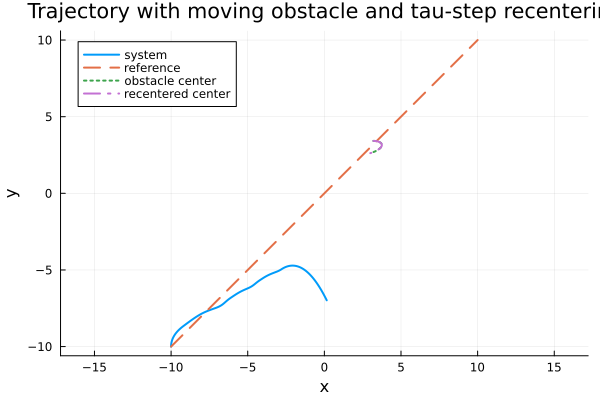

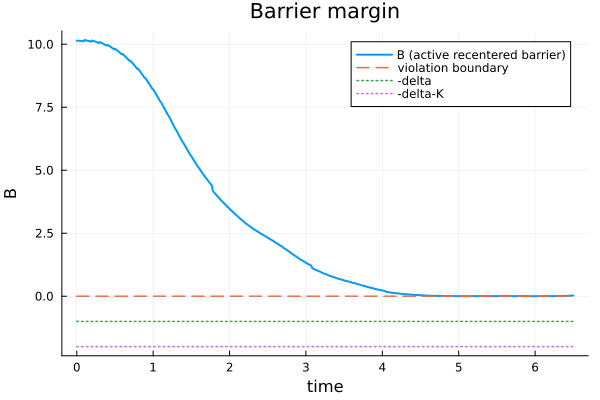

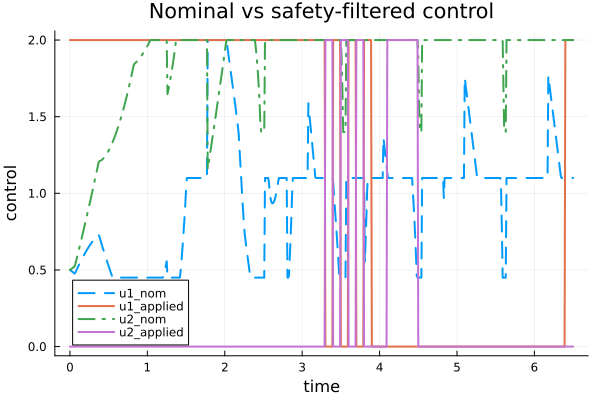

Override steps (total): 650
Emergency override steps (red markers): 0
Min distance to obstacle center: 8.9496 (radius = 0.1)
Collision detected (distance <= radius): false
Saved GIF: figures/repulsive_hybrid_planar_multirotor.gif


In [11]:
include("Repulsive_hybrid_planar_multirotor7D_recenter_fix.jl")

all_B = [B_1, B_2, B_3, B_4]
# K_sim = maximum([K_1, K_2, K_3, K_4])
K_sim = K

res = RepulsiveHybridPlanarMultirotorRecenterFix.run_repulsive_hybrid_planar_multirotor_demo(
    Bs = all_B,
    U = U,
    K = K_sim,
    delta = 1.0,
    alpha = 0.1,
    tau = 0.1,
    dt = 0.01,
    T = 6.5,
    x0 = [-10.0, -10.0, 0.0, 0.0, 0.0, 0.0, 0.0],
    ref_start = (-10.0, -10.0),
    ref_end = (10.0, 10.0),
    ref_T = 6.5,
    v_obs = (0.55, 0.42),
    x0_obs = (3.2, 3.0),
    gif_file = "figures/repulsive_hybrid_planar_multirotor.gif",
)

display(res.p_traj)
display(res.p_B)
display(res.p_u)
println("Override steps (total): ", res.n_override)
println("Emergency override steps (red markers): ", res.n_emergency_override)
println("Min distance to obstacle center: ", round(res.min_dist_to_obs, digits=4), " (radius = 0.1)")
println("Collision detected (distance <= radius): ", res.collision)
println("Saved GIF: ", res.gif_path)